### Research Question

What racial disparities are present regarding asthma and chronic obstructive pulmonary disorder (COPD) prevalence, and which U.S states show the greatest disparities?

In [1]:
import numpy as np                
import pandas as pd              
import matplotlib.pyplot as plt   
import seaborn as sns               

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
path = pd.read_csv('U.S._Chronic_Disease_Indicators.csv')
cdi_df = pd.DataFrame(path)

In [3]:
cdi_df.head(5)

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2019,2019,GA,Georgia,BRFSS,Disability,Adults with any disability,NaN,%,Crude Prevalence,44.0,44.0,NaN,NaN,41.0,47.1,Age,Age >=65,NaN,NaN,NaN,NaN,POINT (-83.62758034599966 32.83968109300048),13,DIS,DIS01,NaN,CRDPREV,AGE,AGE65P,NaN,NaN,NaN,NaN
1,2019,2019,GU,Guam,BRFSS,Arthritis,Arthritis among adults,NaN,%,Crude Prevalence,15.9,15.9,NaN,NaN,13.3,18.9,Sex,Female,NaN,NaN,NaN,NaN,POINT (144.793731 13.444304),66,ART,ART01,NaN,CRDPREV,SEX,SEXF,NaN,NaN,NaN,NaN
2,2019,2019,GU,Guam,BRFSS,Immunization,Influenza vaccination among adults,NaN,%,Crude Prevalence,30.0,30.0,NaN,NaN,26.2,34.0,Sex,Male,NaN,NaN,NaN,NaN,POINT (144.793731 13.444304),66,IMM,IMM01,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
3,2019,2019,ME,Maine,BRFSS,Diabetes,Diabetes among adults,NaN,%,Crude Prevalence,11.4,11.4,NaN,NaN,10.2,12.7,Sex,Male,NaN,NaN,NaN,NaN,POINT (-68.98503133599962 45.254228894000505),23,DIA,DIA01,NaN,CRDPREV,SEX,SEXM,NaN,NaN,NaN,NaN
4,2019,2019,NV,Nevada,NVSS,Health Status,Life expectancy at birth,NaN,Years,Number,78.0,78.0,NaN,NaN,77.8,78.2,Overall,Overall,NaN,NaN,NaN,NaN,POINT (-117.07184056399967 39.493240390000494),32,HEA,HEA06,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN


In [4]:
cdi_df.info(show_counts=True, verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311745 entries, 0 to 311744
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  311745 non-null  int64  
 1   YearEnd                    311745 non-null  int64  
 2   LocationAbbr               311745 non-null  object 
 3   LocationDesc               311745 non-null  object 
 4   DataSource                 311745 non-null  object 
 5   Topic                      311745 non-null  object 
 6   Question                   311745 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              311745 non-null  object 
 9   DataValueType              311745 non-null  object 
 10  DataValue                  210684 non-null  float64
 11  DataValueAlt               210684 non-null  float64
 12  DataValueFootnoteSymbol    102758 non-null  object 
 13  DataValueFootnote          10

In [5]:
cdi_df.isnull().sum()

YearStart                         0
YearEnd                           0
LocationAbbr                      0
LocationDesc                      0
DataSource                        0
Topic                             0
Question                          0
Response                     311745
DataValueUnit                     0
DataValueType                     0
DataValue                    101061
DataValueAlt                 101061
DataValueFootnoteSymbol      208987
DataValueFootnote            208987
LowConfidenceLimit           121372
HighConfidenceLimit          121367
StratificationCategory1           0
Stratification1                   0
StratificationCategory2      311745
Stratification2              311745
StratificationCategory3      311745
Stratification3              311745
Geolocation                    5809
LocationID                        0
TopicID                           0
QuestionID                        0
ResponseID                   311745
DataValueTypeID             

In [6]:
cdi_df.shape

(311745, 34)

In [7]:
def missing(DataFrame):
    print('Percentage of missing values in the dataset:\n',
          round((DataFrame.isnull().sum() *100/len(DataFrame)), 2).sort_values(ascending=False))

missing(cdi_df)

Percentage of missing values in the dataset:
 StratificationCategoryID3    100.00
Response                     100.00
ResponseID                   100.00
StratificationCategory2      100.00
StratificationID2            100.00
StratificationCategoryID2    100.00
Stratification3              100.00
StratificationCategory3      100.00
Stratification2              100.00
StratificationID3            100.00
DataValueFootnoteSymbol       67.04
DataValueFootnote             67.04
LowConfidenceLimit            38.93
HighConfidenceLimit           38.93
DataValueAlt                  32.42
DataValue                     32.42
Geolocation                    1.86
YearStart                      0.00
YearEnd                        0.00
Stratification1                0.00
DataSource                     0.00
LocationDesc                   0.00
Topic                          0.00
Question                       0.00
DataValueUnit                  0.00
DataValueType                  0.00
LocationAbbr      

In [8]:
dropCols = ['StratificationCategoryID3','Response','ResponseID','StratificationCategory2','StratificationID2',
            'StratificationCategoryID2','Stratification3','StratificationCategory3','Stratification2', 'StratificationID3']

cdi_df = cdi_df.drop(columns=dropCols)
cdi_df.head(5) 

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
0,2019,2019,GA,Georgia,BRFSS,Disability,Adults with any disability,%,Crude Prevalence,44.0,44.0,NaN,NaN,41.0,47.1,Age,Age >=65,POINT (-83.62758034599966 32.83968109300048),13,DIS,DIS01,CRDPREV,AGE,AGE65P
1,2019,2019,GU,Guam,BRFSS,Arthritis,Arthritis among adults,%,Crude Prevalence,15.9,15.9,NaN,NaN,13.3,18.9,Sex,Female,POINT (144.793731 13.444304),66,ART,ART01,CRDPREV,SEX,SEXF
2,2019,2019,GU,Guam,BRFSS,Immunization,Influenza vaccination among adults,%,Crude Prevalence,30.0,30.0,NaN,NaN,26.2,34.0,Sex,Male,POINT (144.793731 13.444304),66,IMM,IMM01,CRDPREV,SEX,SEXM
3,2019,2019,ME,Maine,BRFSS,Diabetes,Diabetes among adults,%,Crude Prevalence,11.4,11.4,NaN,NaN,10.2,12.7,Sex,Male,POINT (-68.98503133599962 45.254228894000505),23,DIA,DIA01,CRDPREV,SEX,SEXM
4,2019,2019,NV,Nevada,NVSS,Health Status,Life expectancy at birth,Years,Number,78.0,78.0,NaN,NaN,77.8,78.2,Overall,Overall,POINT (-117.07184056399967 39.493240390000494),32,HEA,HEA06,NMBR,OVERALL,OVR


In [9]:
cdi_df["StratificationCategory1"].unique()

array(['Age', 'Sex', 'Overall', 'Race/Ethnicity', 'Grade'], dtype=object)

In [10]:
cdi_df.shape

(311745, 24)

In [11]:
cdi_df.isnull().sum()

YearStart                         0
YearEnd                           0
LocationAbbr                      0
LocationDesc                      0
DataSource                        0
Topic                             0
Question                          0
DataValueUnit                     0
DataValueType                     0
DataValue                    101061
DataValueAlt                 101061
DataValueFootnoteSymbol      208987
DataValueFootnote            208987
LowConfidenceLimit           121372
HighConfidenceLimit          121367
StratificationCategory1           0
Stratification1                   0
Geolocation                    5809
LocationID                        0
TopicID                           0
QuestionID                        0
DataValueTypeID                   0
StratificationCategoryID1         0
StratificationID1                 0
dtype: int64

In [12]:
cdi_df["Topic"].unique()

array(['Disability', 'Arthritis', 'Immunization', 'Diabetes',
       'Health Status', 'Alcohol', 'Asthma', 'Sleep', 'Oral Health',
       'Mental Health', 'Cardiovascular Disease', 'Cancer', 'Tobacco',
       'Nutrition, Physical Activity, and Weight Status',
       'Chronic Obstructive Pulmonary Disease',
       'Social Determinants of Health', 'Cognitive Health and Caregiving',
       'Maternal Health', 'Chronic Kidney Disease'], dtype=object)

In [13]:
cdi_df = cdi_df[(cdi_df["Topic"] == "Asthma") | (cdi_df["Topic"] == "Chronic Obstructive Pulmonary Disease")]

In [14]:
cdi_df.head(5)

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
11,2020,2020,DC,District of Columbia,BRFSS,Asthma,Current asthma among adults,%,Crude Prevalence,8.7,8.7,NaN,NaN,7.0,10.8,Sex,Male,POINT (-77.036871 38.907192),11,AST,AST02,CRDPREV,SEX,SEXM
12,2020,2020,GU,Guam,BRFSS,Asthma,Current asthma among adults,%,Crude Prevalence,3.1,3.1,NaN,NaN,2.0,4.9,Sex,Male,POINT (144.793731 13.444304),66,AST,AST02,CRDPREV,SEX,SEXM
13,2020,2020,IL,Illinois,NVSS,Asthma,"Asthma mortality among all people, underlying ...",Number,Number,88.0,88.0,NaN,NaN,NaN,NaN,Sex,Female,POINT (-88.99771017799969 40.48501028300046),17,AST,AST01,NMBR,SEX,SEXF
18,2020,2020,US,United States,BRFSS,Asthma,Current asthma among adults,%,Crude Prevalence,7.3,7.3,NaN,NaN,7.0,7.5,Sex,Male,NaN,59,AST,AST02,CRDPREV,SEX,SEXM
23,2020,2020,WA,Washington,BRFSS,Asthma,Current asthma among adults,%,Crude Prevalence,7.6,7.6,NaN,NaN,6.8,8.5,Sex,Male,POINT (-120.47001078999972 47.52227862900048),53,AST,AST02,CRDPREV,SEX,SEXM


In [15]:
cdi_df.shape

(38727, 24)

In [16]:
cdi_df["DataValueUnit"].unique()

array(['%', 'Number', 'cases per 100,000', 'cases per 1,000'],
      dtype=object)

In [17]:
cdi_df["Stratification1"].unique()

array(['Male', 'Female', 'Hawaiian or Pacific Islander, non-Hispanic',
       'White, non-Hispanic', 'Hispanic', 'Overall',
       'American Indian or Alaska Native, non-Hispanic', 'Age 18-44',
       'Black, non-Hispanic', 'Age >=65', 'Multiracial, non-Hispanic',
       'Asian or Pacific Islander, non-Hispanic', 'Age 0-44', 'Age 45-64',
       'Asian, non-Hispanic'], dtype=object)

In [18]:
cdi_df["StratificationID1"].unique()

array(['SEXM', 'SEXF', 'HAPI', 'WHT', 'HIS', 'OVR', 'AIAN', 'AGE1844',
       'BLK', 'AGE65P', 'MRC', 'API', 'AGE0_44', 'AGE4564', 'ASN'],
      dtype=object)

In [19]:
cdi_new = cdi_df[
    (cdi_df["StratificationCategory1"] == "Race/Ethnicity") & 
    (cdi_df["DataValueUnit"] == "%")]

In [20]:
cdi_new.head(5)

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
13639,2019,2019,AR,Arkansas,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,26.1,26.1,NaN,NaN,14.8,41.9,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-92.27449074299966 34.74865012400045),5,COPD,COPD01,CRDPREV,RACE,AIAN
13824,2019,2019,AK,Alaska,BRFSS,Chronic Obstructive Pulmonary Disease,Current smoking among adults with chronic obst...,%,Crude Prevalence,NaN,NaN,****,Data suppressed; denominator < 50 or relative ...,NaN,NaN,Race/Ethnicity,"Multiracial, non-Hispanic",POINT (-147.72205903599973 64.84507995700051),2,COPD,COPD02,CRDPREV,RACE,MRC
14057,2019,2019,AL,Alabama,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Age-adjusted Prevalence,15.9,15.9,NaN,NaN,9.9,24.7,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-86.63186076199969 32.84057112200048),1,COPD,COPD01,AGEADJPREV,RACE,AIAN
14118,2019,2019,AR,Arkansas,BRFSS,Chronic Obstructive Pulmonary Disease,Current smoking among adults with chronic obst...,%,Crude Prevalence,40.1,40.1,NaN,NaN,23.2,59.6,Race/Ethnicity,"Black, non-Hispanic",POINT (-92.27449074299966 34.74865012400045),5,COPD,COPD02,CRDPREV,RACE,BLK
14169,2019,2019,AK,Alaska,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Age-adjusted Prevalence,4.8,4.8,NaN,NaN,2.7,8.4,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-147.72205903599973 64.84507995700051),2,COPD,COPD01,AGEADJPREV,RACE,AIAN


In [21]:
cdi_new["DataValue"] = cdi_new["DataValue"].fillna(0)

In [22]:
cdi_new.head(2)

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,Geolocation,LocationID,TopicID,QuestionID,DataValueTypeID,StratificationCategoryID1,StratificationID1
13639,2019,2019,AR,Arkansas,BRFSS,Chronic Obstructive Pulmonary Disease,Chronic obstructive pulmonary disease among ad...,%,Crude Prevalence,26.1,26.1,NaN,NaN,14.8,41.9,Race/Ethnicity,"American Indian or Alaska Native, non-Hispanic",POINT (-92.27449074299966 34.74865012400045),5,COPD,COPD01,CRDPREV,RACE,AIAN
13824,2019,2019,AK,Alaska,BRFSS,Chronic Obstructive Pulmonary Disease,Current smoking among adults with chronic obst...,%,Crude Prevalence,0.0,NaN,****,Data suppressed; denominator < 50 or relative ...,NaN,NaN,Race/Ethnicity,"Multiracial, non-Hispanic",POINT (-147.72205903599973 64.84507995700051),2,COPD,COPD02,CRDPREV,RACE,MRC


In [23]:
cdi_race = cdi_new.groupby(["LocationAbbr","LocationDesc", "Topic", "Stratification1"])["DataValue"].mean().reset_index()
cdi_race.columns = ["State Abr", "State", "Topic", "Race/Ethnicity", "Avg Prevalence"]
cdi_race

,State Abr,State,Topic,Race/Ethnicity,Avg Prevalence
0,AK,Alaska,Asthma,"American Indian or Alaska Native, non-Hispanic",10.40000
1,AK,Alaska,Asthma,"Asian, non-Hispanic",0.00000
2,AK,Alaska,Asthma,"Black, non-Hispanic",1.23750
3,AK,Alaska,Asthma,"Hawaiian or Pacific Islander, non-Hispanic",0.00000
4,AK,Alaska,Asthma,Hispanic,10.00000
5,AK,Alaska,Asthma,"Multiracial, non-Hispanic",10.83750
6,AK,Alaska,Asthma,"White, non-Hispanic",9.82500
7,AK,Alaska,Chronic Obstructive Pulmonary Disease,"American Indian or Alaska Native, non-Hispanic",9.62500
8,AK,Alaska,Chronic Obstructive Pulmonary Disease,"Asian, non-Hispanic",0.00000
9,AK,Alaska,Chronic Obstructive Pulmonary Disease,"Black, non-Hispanic",0.00000


In [24]:
cdi_asthma = cdi_race[cdi_race["Topic"] == "Asthma"]
cdi_copd = cdi_race[cdi_race["Topic"] == "Chronic Obstructive Pulmonary Disease"]

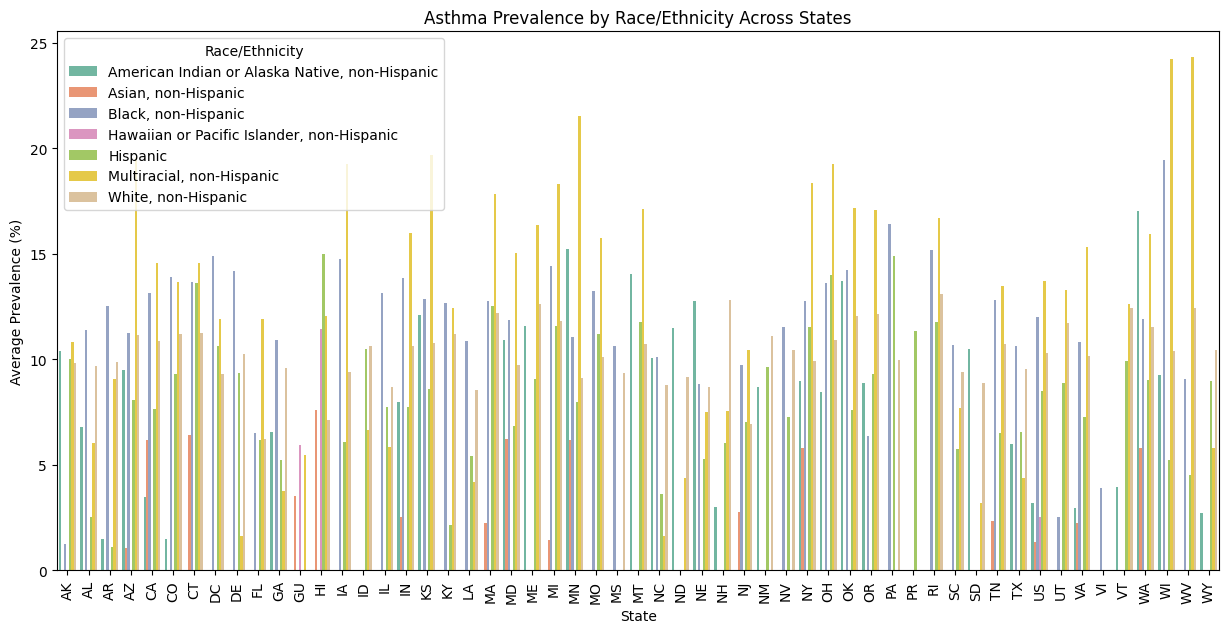

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7)) 

sns.barplot(x="State Abr", y="Avg Prevalence", data=cdi_asthma,
            hue="Race/Ethnicity", palette="Set2", ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.set_xlabel("State")
ax.set_ylabel("Average Prevalence (%)")
ax.set_title("Asthma Prevalence by Race/Ethnicity Across States")
ax.legend(title="Race/Ethnicity")

plt.show()

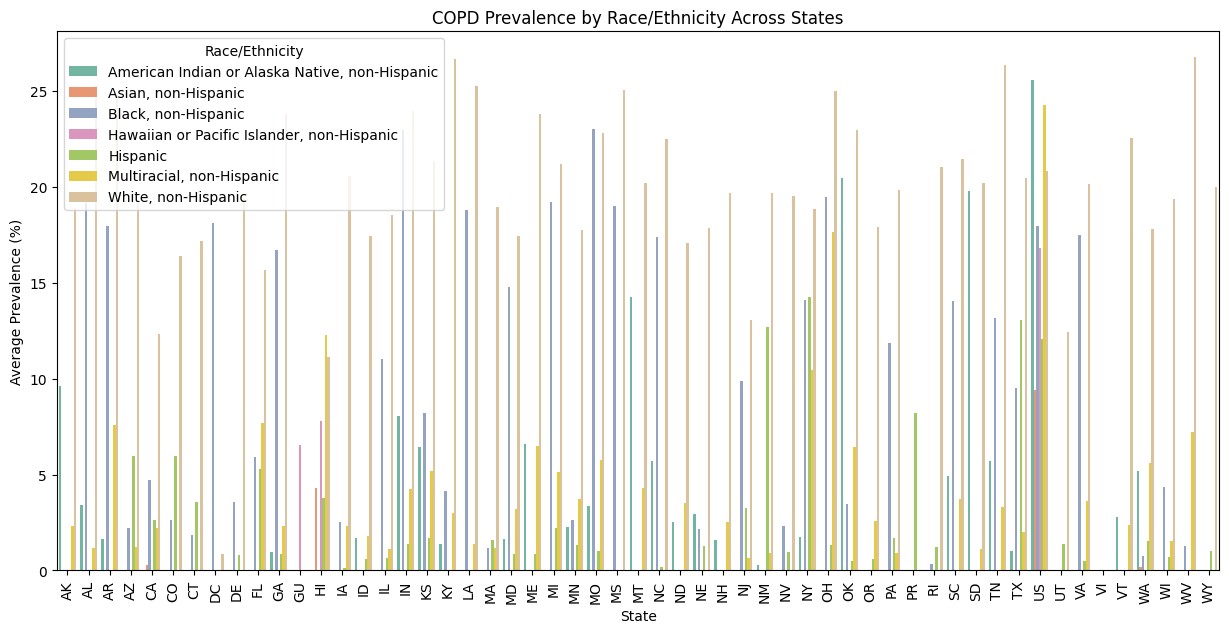

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7)) 

sns.barplot(x="State Abr", y="Avg Prevalence", data=cdi_copd, 
            hue="Race/Ethnicity", palette="Set2", ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.set_xlabel("State")
ax.set_ylabel("Average Prevalence (%)")
ax.set_title("COPD Prevalence by Race/Ethnicity Across States")
ax.legend(title="Race/Ethnicity")

plt.show()